# Left-Tail-Momentum -- a quantitative teardown
### yfinance survivor panel * VaR sort * long-short * one-sample t * placebo null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Left%20tail%20keeps%20losing%3F: Busted](https://img.shields.io/badge/Left%20tail%20keeps%20losing%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test ABDG (2020): sort on trailing 5%/1% VaR (or worst day), long the safe tail, short the crashed tail, one execution lag, monthly hold.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 48 S&P 500 large-cap survivors, 2014-2026, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** the basket is the names still trading in 2026; the worst-tail names that delisted -- the short leg ABDG needs -- are absent.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from left_tail_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "ltm_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "ltm_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    book = st.long_short_book(prices, kind="var5", lookback=252, min_stocks=20,
                              cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls   = st.summary(book["ls_ret"])
    s_net  = st.summary(book["ls_ret_net"])
    s_long = st.summary(book["long_ret"])
    s_short= st.summary(book["short_ret"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 135 | LS mean: -25.39%/yr | one-sample t: -3.436


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-safe/short-crashed **-25.39%/yr**, one-sample *t* = **-3.436** (HAC -3.471) -- significant but **wrong sign** vs the continuation claim. |
| **Tradability** | `MIRAGE` | Sharpe **-1.025**, max DD **-96.1%**, short leg = decade's winners. |
| **Left tail keeps losing?** | `BUSTED` | Loses 11 of 12 years; crashed survivors rebound. |

> A real, robust cross-sectional signal -- pointing **reverse** of ABDG (2020). On survivors, short-run reversal beats left-tail momentum.

## 1 -- The claim, steelmanned

Let $\text{VaR}^{5}_{i,t}$ = the 5th-percentile daily return of stock $i$ over the trailing year at $t$ (a negative number; more negative = worse left tail). ABDG (2020) assert:

- **H1 (continuation).** Stocks with the worst (most negative) VaR keep underperforming next month: $E[r^{\text{worst}}_{t+1}] < E[r^{\text{safe}}_{t+1}]$, so the spread $r^{\text{safe}} - r^{\text{worst}} > 0$.
- **H2 (under-reaction).** The driver is slow incorporation of bad news, strongest where arbitrage is costly (illiquid, high-idio-vol).

We test H1 directly on large-caps. The competing hypothesis is short-run reversal (Jegadeesh 1990): $r^{\text{worst}} - r^{\text{safe}} > 0$ instead. The data pick **reversal** -- the spread is large and *negative*.

## 2 -- So what? -- the economic stakes

Left-tail momentum is one of the cleaner *behavioural* anomalies in the post-2010 literature -- a slow-bleeding under-reaction to bad news. If it survives on tradable large-caps, it is a deployable short signal. If it inverts -- as here -- it is a case study in how survivorship and reversal conspire to flip a published factor's sign on the part of the universe you can actually hold.

## 3 -- The protocol

- **Signal.** Trailing 252-day left-tail statistic per stock: `var5` (5% quantile), `var1` (1% quantile), or `worst` (min daily return).
- **Ranking.** Monthly, sort the 48 names; quintile groups (or median split if thin).
- **Long leg.** Equal-weight the safe tail (least-negative VaR).
- **Short leg.** Equal-weight the crashed tail (most-negative VaR).
- **Execution lag.** Enter the close one trading day after the month-end signal; hold the next calendar month. No same-bar fill.
- **Inference.** One-sample *t* on the monthly spread (bar |t| >= 2), HAC *t* alongside, a 200-draw placebo label-shuffle null.
- **Costs.** 5 bps/leg x turnover + 50 bps/yr borrow on the short leg; gross vs net.
- **Universe caveat.** 48 large-cap survivors -- survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector (seed-robust)

Plant a left-tail-momentum premium across many seeds and average the one-sample t (Welch-style, so no claim rests on one lucky RNG). The mean should rise with the premium and stay positive. (3 seeds for the figure; docs/results.md uses 20.)

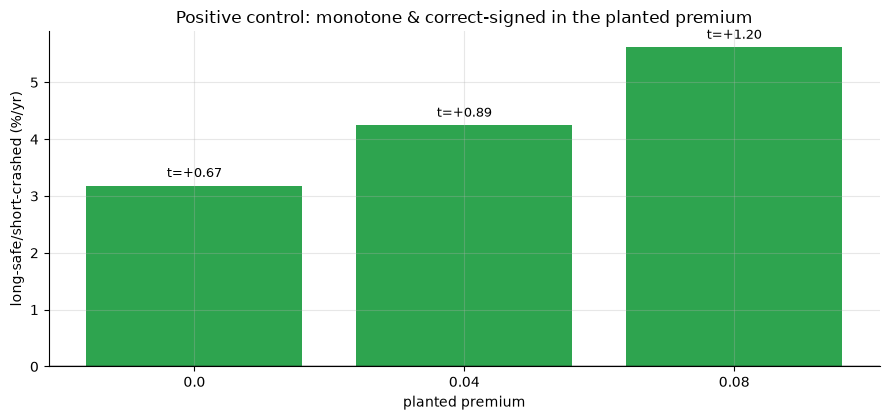

 premium  mean_ls_pct  mean_t  share_t2
    0.00        3.184   0.671       0.0
    0.04        4.245   0.891       0.0
    0.08        5.617   1.199       0.0

Frozen 20-seed control (docs/results.md):
  premium +0.00: mean +3.89%/yr | avg t +0.840 | share(t>=2) 10%
  premium +0.04: mean +5.05%/yr | avg t +1.091 | share(t>=2) 15%
  premium +0.08: mean +6.09%/yr | avg t +1.317 | share(t>=2) 25%


In [2]:
ctrl = st.synthetic_control(data, premiums=(0.0, 0.04, 0.08), n_seeds=3,
                            kind='var5', lookback=252, base_seed=505)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['mean_ls_pct']]
ax.bar(ctrl['premium'].astype(str), ctrl['mean_ls_pct'], color=col)
for i, (m, t) in enumerate(zip(ctrl['mean_ls_pct'], ctrl['mean_t'])):
    ax.text(i, m + 0.15, f't={t:+.2f}', ha='center', fontsize=9)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted premium'); ax.set_ylabel('long-safe/short-crashed (%/yr)')
ax.set_title('Positive control: monotone & correct-signed in the planted premium')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))
print('\nFrozen 20-seed control (docs/results.md):')
for p,(m,t,sh) in {0.00:(3.89,0.840,10),0.04:(5.05,1.091,15),0.08:(6.09,1.317,25)}.items():
    print(f'  premium {p:+.2f}: mean {m:+.2f}%/yr | avg t {t:+.3f} | share(t>=2) {sh}%')

Faithful but **under-powered** at 48 names: even a planted premium of 0.08 averages *t* ~1.3 (only 25% of seeds clear t>=2). So the engine could only confirm a *large* real continuation -- yet the real tape is significant in the **opposite** sign, which no faithful detector confuses for continuation.

### 4b -- The real long-short and its legs

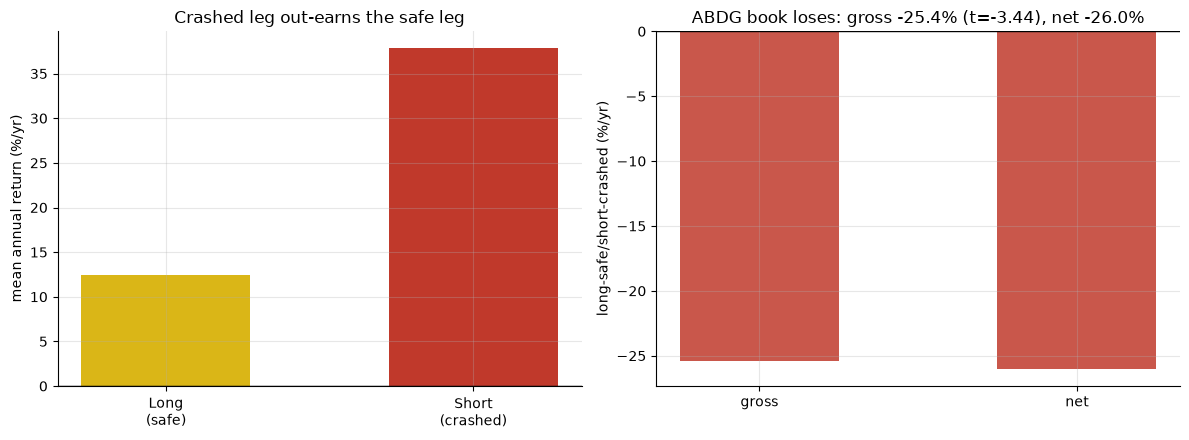

Spread gross -25.39%/yr | one-sample t -3.436 | HAC t -3.471
Spread net   -26.04%/yr | one-sample t -3.523


In [3]:
if HAVE_REAL:
    ls_m = s_ls['mean']*100; ls_t = s_ls['tstat']; ls_hac = s_ls['hac_t']
    lo_m = s_long['mean']*100; sh_m = s_short['mean']*100
    net_m = s_net['mean']*100; net_t = s_net['tstat']
else:
    ls_m, ls_t, ls_hac = R['ls_mean'], R['ls_t'], R['ls_hac']
    lo_m, sh_m = R['long_mean'], R['short_mean']
    net_m, net_t = R['ls_net'], R['ls_net_t']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Long\n(safe)', 'Short\n(crashed)'], [lo_m, sh_m],
            color=[AMBER, RED], width=0.55)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Crashed leg out-earns the safe leg')

# gross vs net spread
axes[1].bar(['gross', 'net'], [ls_m, net_m], color=[RED, RED], width=0.5, alpha=0.85)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('long-safe/short-crashed (%/yr)')
axes[1].set_title(f'ABDG book loses: gross {ls_m:+.1f}% (t={ls_t:+.2f}), net {net_m:+.1f}%')
plt.tight_layout(); plt.show()
print(f'Spread gross {ls_m:+.2f}%/yr | one-sample t {ls_t:+.3f} | HAC t {ls_hac:+.3f}')
print(f'Spread net   {net_m:+.2f}%/yr | one-sample t {net_t:+.3f}')

> The spread is **-25.39%/yr** at one-sample *t* = **-3.436** (HAC -3.471). Costs barely move it (turnover ~12%/mo). The signal is real -- and the *reverse* of ABDG.

### 4c -- The placebo: is the (wrong-sign) signal real, or noise?

In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(prices, kind='var5', lookback=252, min_stocks=20,
                           n_shuffles=200, seed=505)
    real_mo = pl['real_mean']*100; pval = pl['p_value']
else:
    real_mo, pval = R['placebo_real_mo'], R['placebo_p']
print(f'Real mean spread/month: {real_mo:+.3f}%')
print(f'Placebo p-value (200 random sorts): {pval:.3f}')
print('Interpretation: the real left-tail sort is more extreme (negative) than'
      f' {(1-pval)*100:.0f}% of random sorts -> the reversal is real, not noise.')

Real mean spread/month: -2.116%
Placebo p-value (200 random sorts): 0.000
Interpretation: the real left-tail sort is more extreme (negative) than 100% of random sorts -> the reversal is real, not noise.


### 4d -- Flavour & lookback sweep -- is the inversion robust?

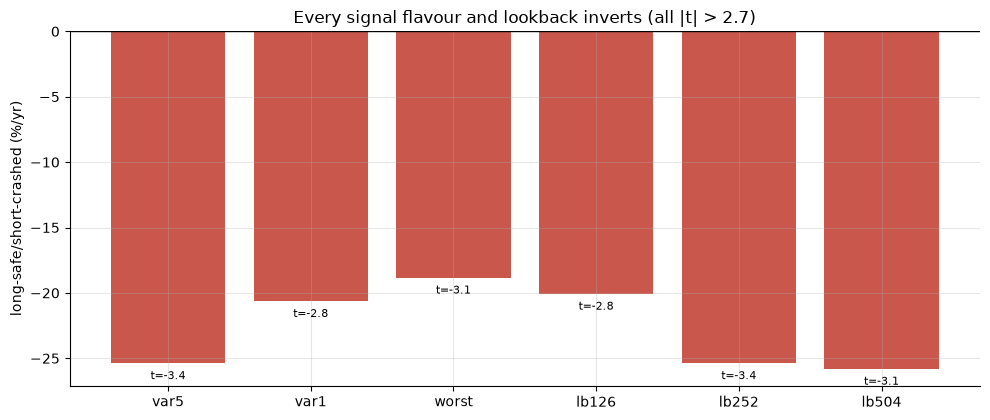

 spec  mean_%      t
 var5 -25.392 -3.436
 var1 -20.645 -2.811
worst -18.851 -3.119
lb126 -20.085 -2.755
lb252 -25.392 -3.436
lb504 -25.821 -3.079


In [5]:
rows = []
if HAVE_REAL:
    for kind in ('var5', 'var1', 'worst'):
        b = st.long_short_book(prices, kind=kind, lookback=252, min_stocks=20)
        s = st.summary(b['ls_ret'])
        rows.append({'spec': kind, 'mean_%': s['mean']*100, 't': s['tstat']})
    for lb in (126, 252, 504):
        if len(prices) > lb:
            b = st.long_short_book(prices, kind='var5', lookback=lb, min_stocks=20)
            s = st.summary(b['ls_ret'])
            rows.append({'spec': f'lb{lb}', 'mean_%': s['mean']*100, 't': s['tstat']})
else:
    for k,(m,t) in R['sweep'].items(): rows.append({'spec': k, 'mean_%': m, 't': t})
    for lb,(m,t) in R['lookback'].items(): rows.append({'spec': f'lb{lb}', 'mean_%': m, 't': t})
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(sweep['spec'], sweep['mean_%'], color=RED, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(sweep['mean_%'], sweep['t'])):
    ax.text(i, m - 1.2, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_ylabel('long-safe/short-crashed (%/yr)')
ax.set_title('Every signal flavour and lookback inverts (all |t| > 2.7)')
plt.tight_layout(); plt.show()
print(sweep.round(3).to_string(index=False))

### 4e -- Equity curve and the -96% drawdown

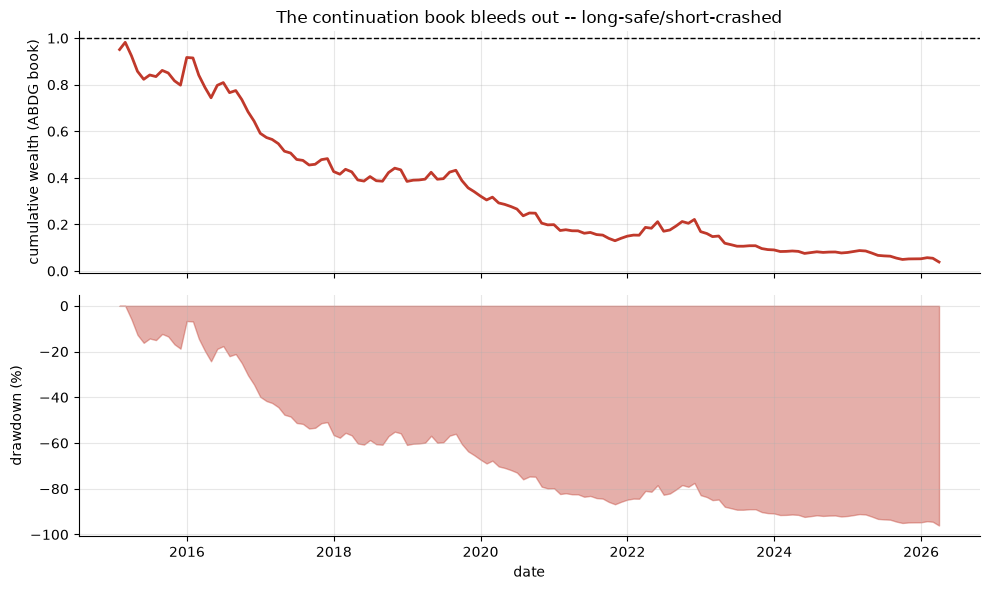

Max drawdown: -96.1% | Hit rate: 37.0%


In [6]:
if HAVE_REAL:
    eq = (1 + book['ls_ret']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(book.index, eq.values, c=RED, lw=2)
    ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth (ABDG book)')
    ax1.set_title('The continuation book bleeds out -- long-safe/short-crashed')
    ax2.fill_between(book.index, dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)'); ax2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | Hit rate: {s_ls["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD = {R["ls_dd"]:.1f}% | hit rate = {R["ls_hit"]:.1f}%')

### 4f -- Year-by-year

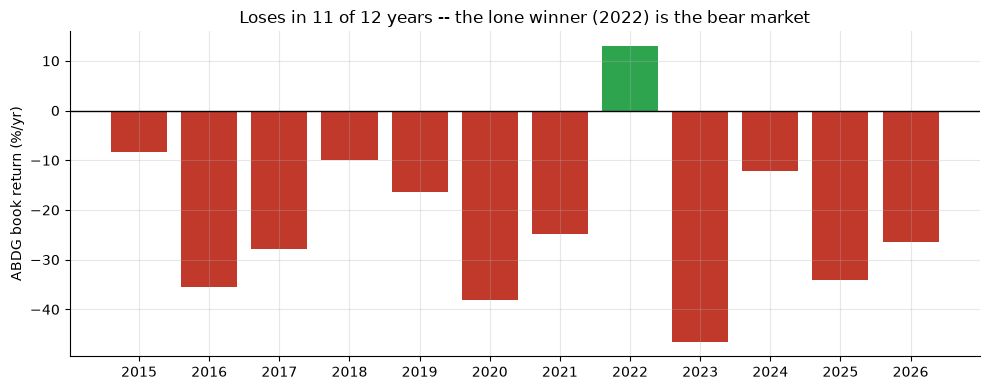

{2015: np.float64(-8.3), 2016: np.float64(-35.5), 2017: np.float64(-27.8), 2018: np.float64(-9.9), 2019: np.float64(-16.3), 2020: np.float64(-38.2), 2021: np.float64(-24.8), 2022: np.float64(13.0), 2023: np.float64(-46.5), 2024: np.float64(-12.1), 2025: np.float64(-34.1), 2026: np.float64(-26.4)}


In [7]:
if HAVE_REAL:
    bc = book.copy(); bc['year'] = bc.index.year
    annual = bc.groupby('year')['ls_ret'].apply(lambda x: float((1+x).prod()-1))*100
    yrs, vals = list(annual.index), list(annual.values)
else:
    yrs, vals = list(R['annual'].keys()), list(R['annual'].values())
fig, ax = plt.subplots(figsize=(10, 4.0))
col = [GREEN if v > 0 else RED for v in vals]
ax.bar([str(y) for y in yrs], vals, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('ABDG book return (%/yr)')
ax.set_title('Loses in 11 of 12 years -- the lone winner (2022) is the bear market')
plt.tight_layout(); plt.show()
print({y: round(v,1) for y, v in zip(yrs, vals)})

## 5 -- The verdict

- **Signal `NONE`** -- the ABDG continuation inverts: -25.39%/yr at one-sample *t* = -3.436 (HAC -3.471), placebo p = 0.000. Real, robust -- but *reversal*, not momentum. On the claim as written, NONE.
- **Tradability `MIRAGE`** -- Sharpe -1.025, max DD -96.1%, the short leg is the decade's winners; costs are immaterial to a wrong-sign book.
- **Left tail keeps losing? `BUSTED`** -- crashed survivors rebound; the book loses 11 of 12 years.

## 6 -- Could you trade it?

No -- and the *reason* is the lesson. ABDG's continuation needs the names that crashed and **stayed down** (often into delisting). A survivor basket deletes them by construction, leaving 'crashed' names that are disproportionately rebounds, so the sort picks up **short-run reversal** instead. The reversal is itself thin and hard to monetise net of costs in liquid large-caps. There is no deployable trade in either direction here -- the wrong-sign continuation, nor the thin reversal it masks.

## 7 -- Going further

- **Delisting-complete universe.** A CRSP/Compustat panel with delisting returns is the only fair test of H1 -- the short leg is the crash-into-delisting names.
- **Costly-arbitrage tilt.** ABDG's effect concentrates in illiquid, high-idio-vol names; large-caps are the worst place to look.
- **Expected Shortfall.** ABDG also use ES (average of the tail) -- swap `left_tail_signal` for a mean-below-quantile variant.
- **[Study 53 -- Jackpot](../../53-jackpot/)** & **[365 -- Lottery-MAX](../../365-lottery-max-effect/)**: the right-tail mirror, both None x Mirage on survivors.
- **[Study 332 -- Downside-Beta](../../332-downside-beta/)** and **[238 -- Betting-Against-Beta](../../238-betting-against-beta/)**: cousin cross-sectional-risk factors on the same desk engine.

*Think left-tail momentum holds once you add the delisted crashers and tilt to illiquid names? Fork this, swap the universe, and show t > 2 in the right direction net of borrow. That is the bar.*